/kaggle/input/datasets/tumelomelloww/divorces-2024/DIVORCES2024.csv
ProvinceCode              0
MaleRace                  0
FemaleRace                0
CoupleRace                0
MaleOccupation            0
FemaleOccupation          0
PlaintiffSex              0
MaleStatus                0
FemaleStatus              0
MaleNoTimesMarried        0
FemaleNoTimesMarried      0
HusbandAge                0
WifeAge                   0
SolemnisationCode         0
MarriagePropertySystem    0
MarriageMonth             0
MarriageYear              0
NoOfChildren              0
DivorceMonth              0
DivorceYear               0
DurationOfMarriage        0
MarriageType              0
PolygamousMarriage        0
GroundsForDivorce         0
dtype: int64
254
       ProvinceCode     MaleRace    FemaleRace    CoupleRace  MaleOccupation  \
count  23948.000000  23948.00000  23948.000000  23948.000000    23948.000000   
mean       5.105270      2.08364      2.112243      2.237932       34.799733   
std

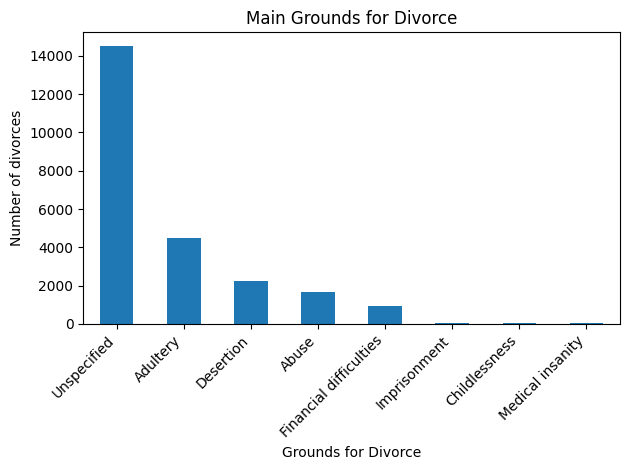

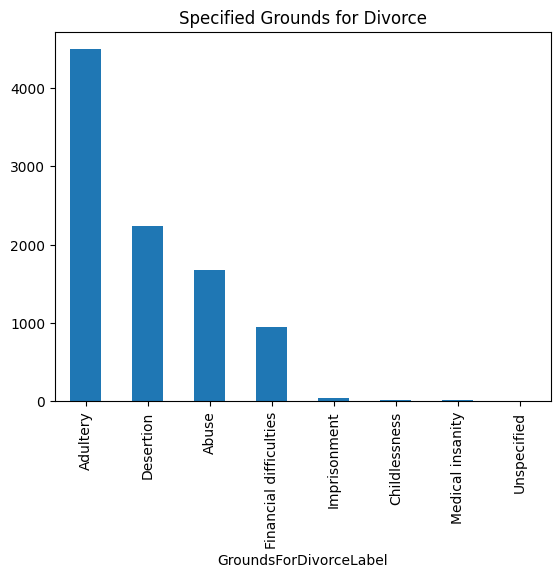

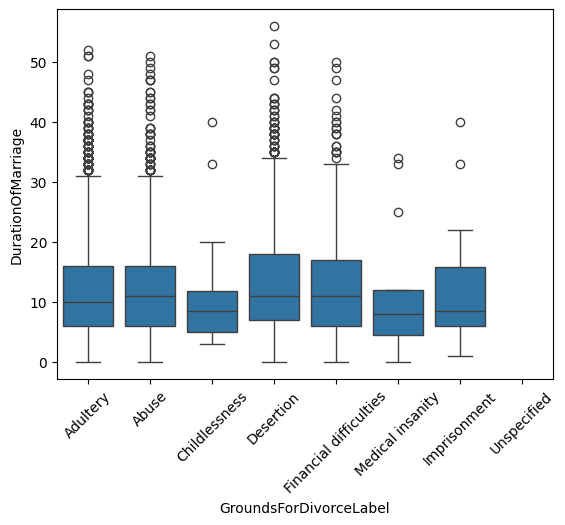

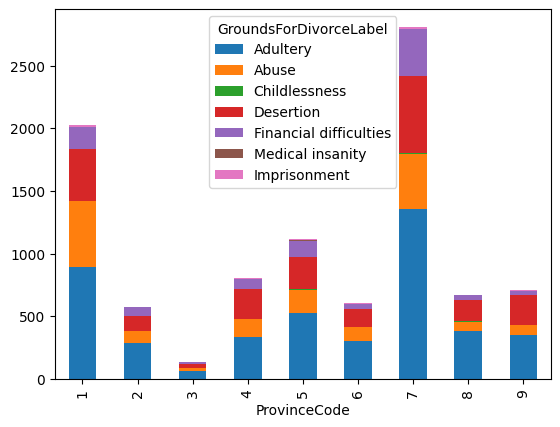

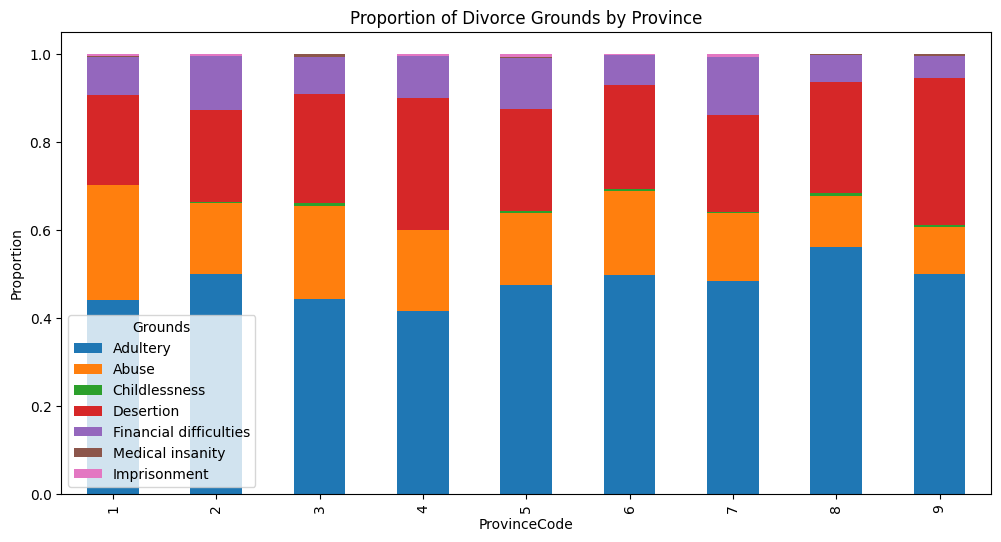

p-value: 3.8388517774533815e-40


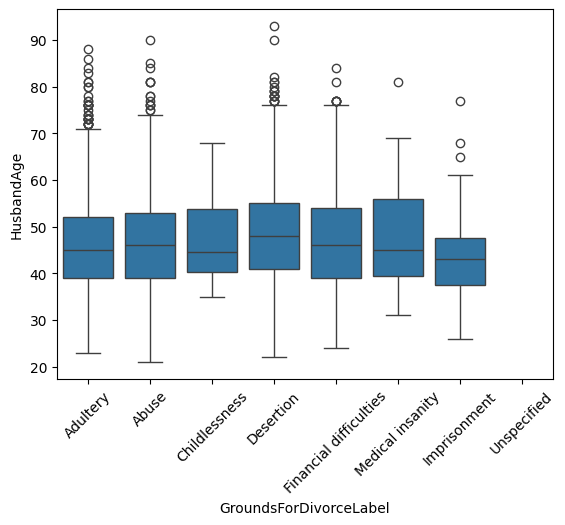

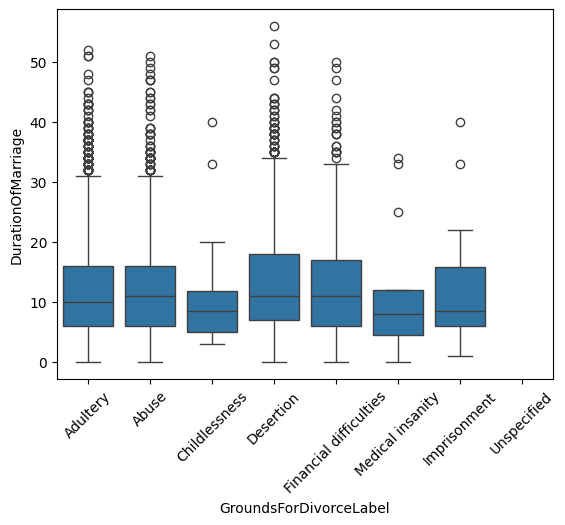

                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                 group2         meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------
                 Abuse               Adultery   -0.859 0.0439  -1.7051 -0.0128   True
                 Abuse          Childlessness   1.0343  0.999  -5.2299  7.2986  False
                 Abuse              Desertion   1.6029    0.0   0.6437  2.5621   True
                 Abuse Financial difficulties   0.4625 0.9189  -0.7441   1.669  False
                 Abuse           Imprisonment  -2.7611 0.5302  -7.2199  1.6977  False
                 Abuse       Medical insanity   2.3949 0.9673  -5.1754  9.9653  False
              Adultery          Childlessness   1.8933 0.9734  -4.3449  8.1316  False
              Adultery              Desertion   2.4619    0.0   1.6908   3.233   True
              Adultery Financial difficulties   1.3215

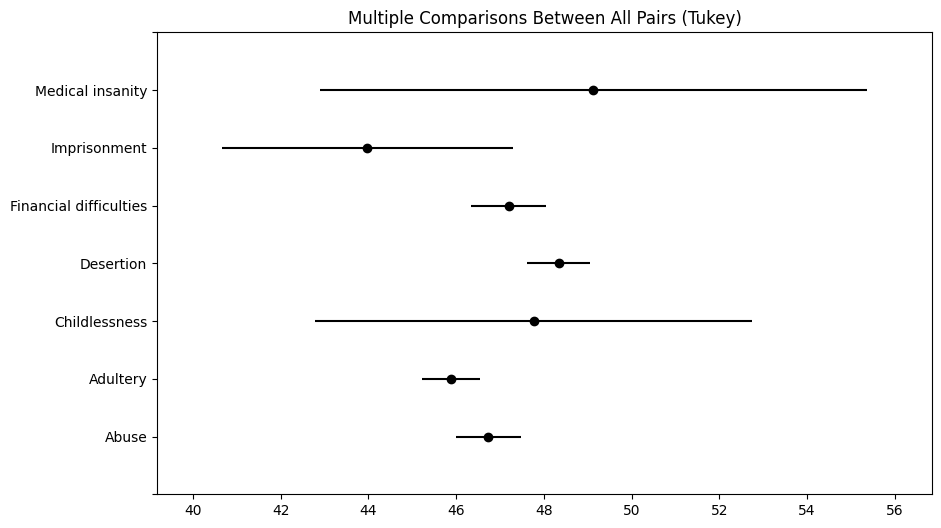

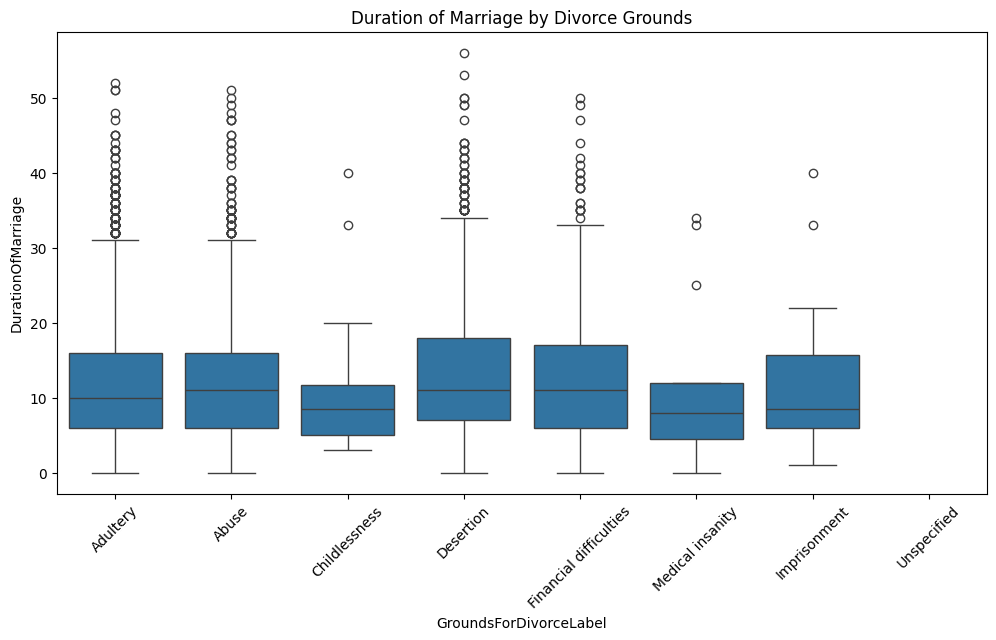

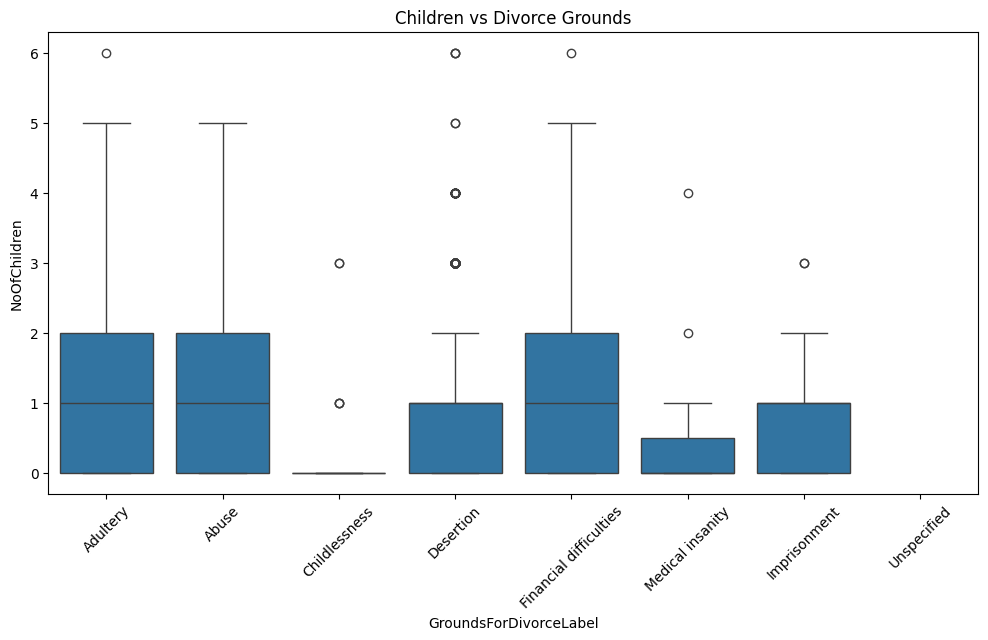

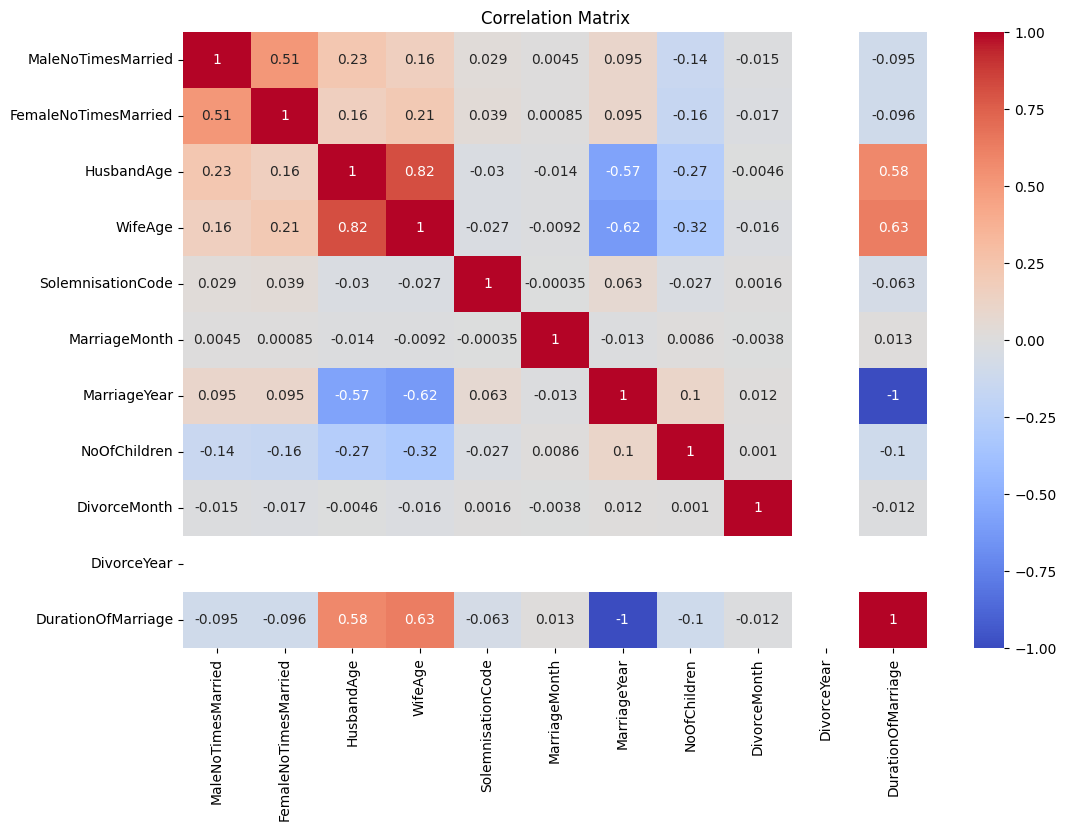

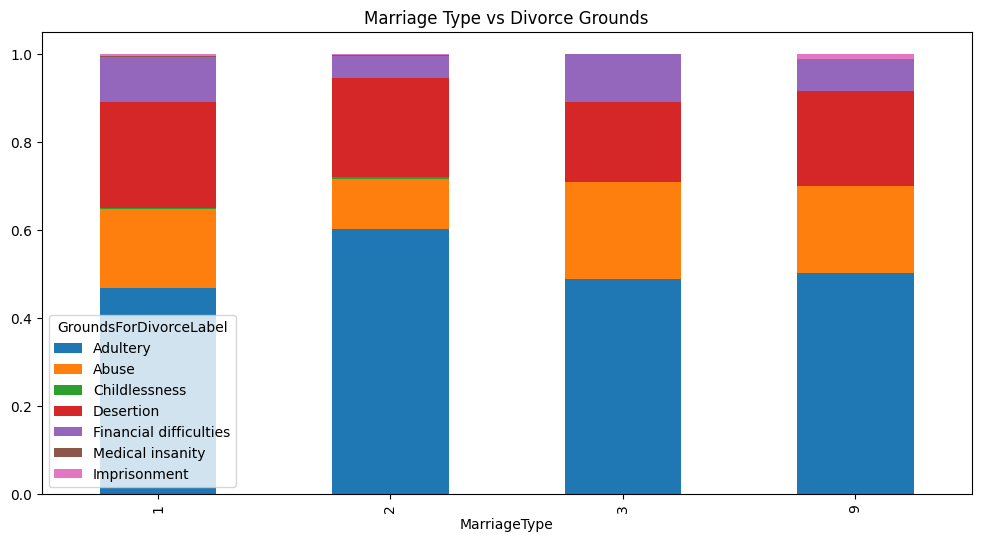

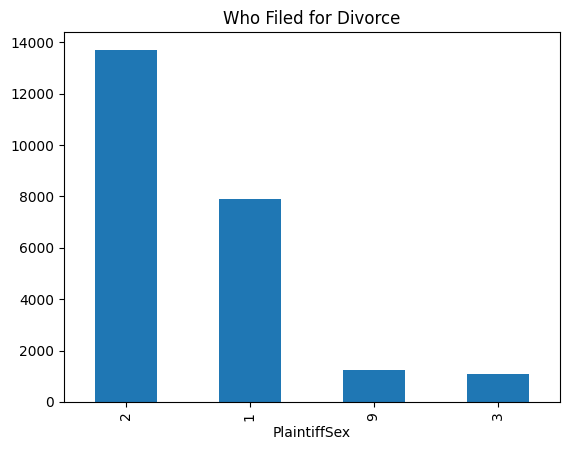

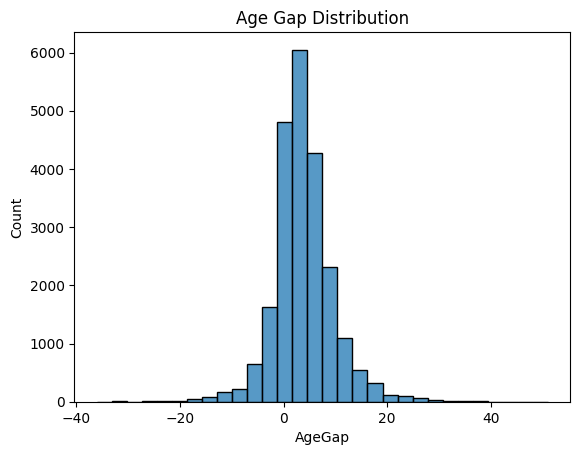

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/tumelomelloww/divorces-2024/DIVORCES2024.csv")
# Basic inspection
#print(df.head())

#print(df.shape)
#print(df.info())

# Missing values
print(df.isnull().sum())
# Duplicate rows
print(df.duplicated().sum())
# Remove duplicates
df = df.drop_duplicates()
# Summary statistics
print(df.describe())

# Histograms
#df.hist(figsize=(12,10))
#plt.show()

# Replace Missing Codes
df.replace({
99: np.nan,
999: np.nan,
9999: np.nan
}, inplace=True)

#Check Missing Values
df.isnull().sum().sort_values(ascending=False)
#Convert Categorical Variables
categorical_cols = [
'ProvinceCode',
'MaleRace',
'FemaleRace',
'CoupleRace',
'MaleOccupation',
'FemaleOccupation',
'PlaintiffSex',
'MaleStatus',
'FemaleStatus',
'MarriagePropertySystem',
'MarriageType',
'PolygamousMarriage',
'GroundsForDivorce'
]
for col in categorical_cols:
    df[col] = df[col].astype('category')


#Plot Divorce Reasons
grounds_map = {
1: "Adultery",
2: "Abuse",
3: "Childlessness",
4: "Desertion",
5: "Financial difficulties",
6: "Medical insanity",
7: "Imprisonment",
9: "Unspecified"
}

df["GroundsForDivorceLabel"] = df["GroundsForDivorce"].map(grounds_map)

df["GroundsForDivorceLabel"].value_counts().plot(kind="bar")

plt.title("Main Grounds for Divorce")
plt.xlabel("Grounds for Divorce")
plt.ylabel("Number of divorces")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

####Remove Unspecified Records
filtered_df = df[df['GroundsForDivorceLabel'] != 'Unspecified']
###Plot Specified Grounds
filtered_df['GroundsForDivorceLabel'].value_counts().plot(kind='bar')
plt.title("Specified Grounds for Divorce")
plt.show()

sns.boxplot(
x='GroundsForDivorceLabel',
y='DurationOfMarriage',
data=filtered_df
)
plt.xticks(rotation=45)
plt.show()
###Grounds by Province
pd.crosstab(
df['ProvinceCode'],
filtered_df['GroundsForDivorceLabel']
).plot(kind='bar', stacked=True)
plt.show()

#Improved Plot 

province_divorce = pd.crosstab(
df['ProvinceCode'],
filtered_df['GroundsForDivorceLabel'],
normalize='index'
)

province_divorce.plot(
kind='bar',
stacked=True,
figsize=(12,6)
)

plt.title("Proportion of Divorce Grounds by Province")
plt.ylabel("Proportion")
plt.legend(title="Grounds")
plt.show()

## Chi-Square Statistical Test
from scipy.stats import chi2_contingency
table = pd.crosstab(
filtered_df['ProvinceCode'],
filtered_df['GroundsForDivorceLabel']
)
chi2, p, dof, expected = chi2_contingency(table)
print("p-value:", p)

## Grounds for Divorce vs Age
sns.boxplot(
x='GroundsForDivorceLabel',
y='HusbandAge',
data=filtered_df
)
plt.xticks(rotation=45)
plt.show()
### Grounds for Divorce vs Duration of Marriage
sns.boxplot(
x='GroundsForDivorceLabel',
y='DurationOfMarriage',
data=filtered_df
)
plt.xticks(rotation=45)
plt.show()

tukey_df = filtered_df[
['HusbandAge', 'GroundsForDivorceLabel']
].dropna()

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(
endog=tukey_df['HusbandAge'],
groups=tukey_df['GroundsForDivorceLabel'],
alpha=0.05
)

print(tukey)

tukey.plot_simultaneous()
plt.show()


#Duration of Marriage Analysis
#Investigate whether certain divorce causes are associated with longer or shorter marriages. This may
#reveal temporal relationship dynamics.
plt.figure(figsize=(12,6))
sns.boxplot(
x='GroundsForDivorceLabel',
y='DurationOfMarriage',
data=filtered_df
)
plt.xticks(rotation=45)
plt.title("Duration of Marriage by Divorce Grounds")
plt.show()


##Number of Children Analysis
##Investigate whether couples with children divorce for different reasons compared to couples without
##children.
plt.figure(figsize=(12,6))
sns.boxplot(
x='GroundsForDivorceLabel',
y='NoOfChildren',
data=filtered_df
)
plt.xticks(rotation=45)
plt.title("Children vs Divorce Grounds")
plt.show()

##Correlation Analysis
##Analyze numerical relationships between continuous variables. Look for strong positive or negative
##relationships.
plt.figure(figsize=(12,8))
sns.heatmap(
df.corr(numeric_only=True),
cmap='coolwarm',
annot=True
)
plt.title("Correlation Matrix")
plt.show()

##4. Marriage Type Analysis
## Investigate whether different marriage types have different divorce patterns.
pd.crosstab(
filtered_df['MarriageType'],
filtered_df['GroundsForDivorceLabel'],
normalize='index'
).plot(
kind='bar',
stacked=True,
figsize=(12,6)
)
plt.title("Marriage Type vs Divorce Grounds")
plt.show()
###5. Plaintiff Sex Analysis
###Analyze who initiates divorce more frequently.
df['PlaintiffSex'].value_counts().plot(kind='bar')
plt.title("Who Filed for Divorce")
plt.show()
##6. Age Gap Feature Engineering
##Create a new feature representing the age difference between spouses and investigate its relationship
##to divorce grounds.
df['AgeGap'] = df['HusbandAge'] - df['WifeAge']
sns.histplot(df['AgeGap'], bins=30)
plt.title("Age Gap Distribution")
plt.show()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session